# Norman GI Truth Definition

Build local GI truth labels directly from the raw Norman truth dataset and inspect the resulting metric distributions.

In [1]:
from __future__ import annotations

import importlib
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

repo_root = Path.cwd().resolve()
while not ((repo_root / "scripts").exists() and (repo_root / "configs").exists()):
    if repo_root.parent == repo_root:
        raise FileNotFoundError("Could not locate repo root containing scripts/ and configs/")
    repo_root = repo_root.parent

import sys
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.norman_gi_truth_builder as norman_gi_truth_builder
importlib.reload(norman_gi_truth_builder)

run_norman_gi_truth_builder = norman_gi_truth_builder.run_norman_gi_truth_builder
repo_root

WindowsPath('E:/CODE/trishift')

In [ ]:
dataset = "norman"
out_root = repo_root / "artifacts" / "analysis" / "norman_gi_truth"
low_quantile = 0.35
high_quantile = 0.65
dataset, out_root, low_quantile, high_quantile

('norman',
 WindowsPath('E:/CODE/trishift/artifacts/analysis/norman_gi_truth'),
 0.2,
 0.8)

In [3]:
result = run_norman_gi_truth_builder(
    dataset=dataset,
    out_root=out_root,
    low_quantile=low_quantile,
    high_quantile=high_quantile,
)
print(f"out_dir: {result['out_dir']}")

out_dir: E:\CODE\trishift\artifacts\analysis\norman_gi_truth


In [4]:
display(result["summary_df"])
display(result["truth_df"].head())
display(result["skipped_df"].head())

,gi_type,gi_label,logic,criteria,positive_n,positive_fraction
0,synergy,Synergy,all,mag:high@q=0.80 thr=0.684689,27,0.206107
1,suppressor,Suppression,all,mag:low@q=0.20 thr=0.451349,27,0.206107
2,neomorphic,Neomorphism,all,corr_fit:low@q=0.20 thr=0.876711,27,0.206107
3,redundancy,Redundancy,all,dcor:high@q=0.80 thr=0.906805,27,0.206107
4,epistasis,Epistasis,all,eq_contr:low@q=0.20 thr=0.68802,27,0.206107
5,strong_interaction,Strong Interaction,all,mag:high@q=0.80 thr=0.684689; corr_fit:low@q=0...,3,0.022901
6,balanced_synergy,Balanced Synergy,all,mag:high@q=0.80 thr=0.684689; eq_contr:high@q=...,11,0.083969
7,dominant_epistasis,Dominant Epistasis,all,eq_contr:low@q=0.20 thr=0.68802; dominance:hig...,18,0.137405


,dataset,condition,single_a,single_b,n_cells_combo,n_cells_single_a,n_cells_single_b,n_genes,truth_c1,truth_c2,...,truth_dcor_second,is_synergy,is_suppressor,is_neomorphic,is_redundancy,is_epistasis,is_strong_interaction,is_balanced_synergy,is_dominant_epistasis,is_any_gi
0,norman,AHR+FEV,AHR+ctrl,FEV+ctrl,264,479,647,5045,0.496161,0.493087,...,0.745168,True,False,False,False,False,False,False,False,True
1,norman,AHR+KLF1,AHR+ctrl,KLF1+ctrl,412,479,1641,5045,0.237460,0.287031,...,0.814102,False,True,False,False,False,False,False,False,True
2,norman,BAK1+BCL2L11,BAK1+ctrl,BCL2L11+ctrl,153,1171,463,5045,0.281507,0.311849,...,0.459504,False,True,True,False,False,False,False,False,True
3,norman,BAK1+KLF1,BAK1+ctrl,KLF1+ctrl,323,1171,1641,5045,0.242837,0.408378,...,0.894758,False,False,False,False,True,False,False,True,True
4,norman,BAK1+TMSB4X,BAK1+ctrl,TMSB4X+ctrl,267,1171,462,5045,0.234257,0.313054,...,0.627202,False,True,False,False,False,False,False,False,True


,condition,skip_reason


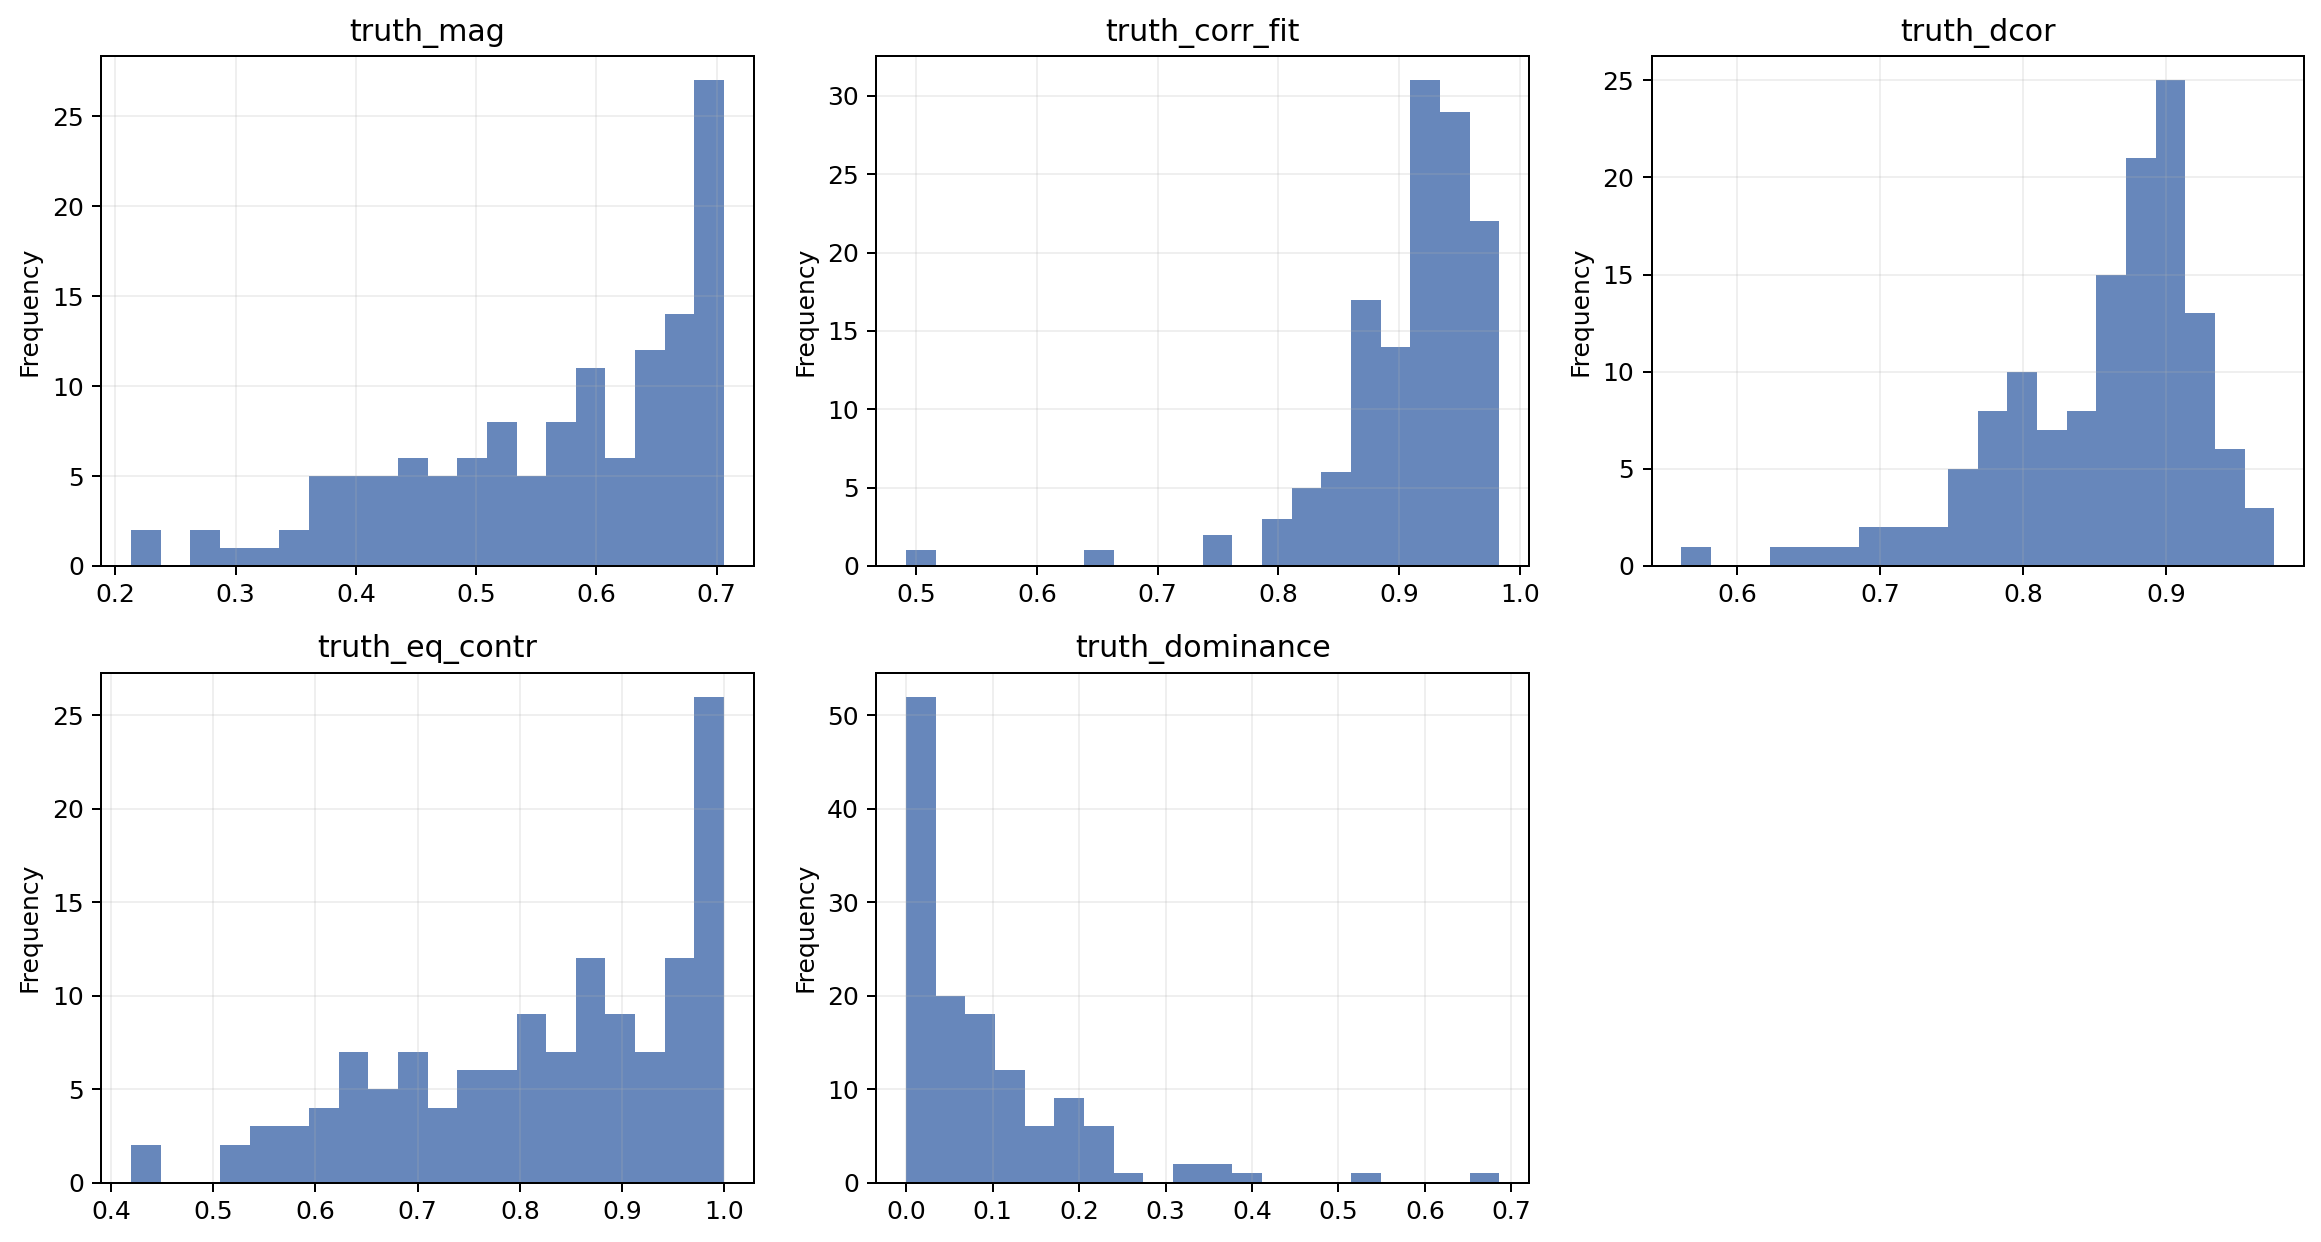

In [5]:
metric_cols = ["truth_mag", "truth_corr_fit", "truth_dcor", "truth_eq_contr", "truth_dominance"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=180)
axes_flat = axes.flatten()
for ax, col in zip(axes_flat, metric_cols):
    result["truth_df"][col].dropna().plot(kind="hist", bins=20, ax=ax, color="#4C72B0", alpha=0.85)
    ax.set_title(col)
    ax.grid(alpha=0.2)
for ax in axes_flat[len(metric_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
truth_labels_path = result["out_dir"] / "norman_gi_truth_labels.csv"
truth_labels_path

WindowsPath('E:/CODE/trishift/artifacts/analysis/norman_gi_truth/norman_gi_truth_labels.csv')

In [7]:
sorted(str(p) for p in result["out_dir"].glob("*"))

['E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_truth\\norman_gi_truth_labels.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_truth\\norman_gi_truth_skipped.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_truth\\norman_gi_truth_sources.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_truth\\norman_gi_truth_summary.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_truth\\run_meta.json']